# Simple Example using Simulated Data

To get started with StanBKT, use this example to explore the following concepts:

1. How to simulate data using `sim_simple_BKT`
2. How to instantiate a model for MCMC fitting.
3. How to specify priors and stan compile arguments.
4. How to fit the model to the data


## Simulate BKT data

The data generation process is based on the standard BKT model with population wide parameters.


In [1]:
from stanbkt.utils import sim_simple_BKT

In [2]:
# define ground truth BKT parameters for data simulation
N_KCS = 2  # we will simulate data for 2 KCs
bkt_params = {  # define BKT parameters for each KCs
    "prior": [0.4, 0.1],
    "learn": [0.04, 0.08],
    "forget": [0.01, 0.005],
    "guess": [0.1, 0.3],
    "slip": [0.05, 0.05],
}

In [3]:
data_df = sim_simple_BKT(
    n_students=30,  # 30 students
    n_problems=60,  # 60 problems
    n_kcs=2,  # 2 knowledge components
    frac=0.8,  # sample 80% of generated data (simulates missing data)
    rng_seed=12345,  # random seed for reproducibility
    **bkt_params,  # use the defined BKT parameters for data simulation
)

StanBKT expects data in long format with 4 required columns:

1. Student ID: ID of the student
2. Problem ID: ID of the problem
3. Correctness: Binary (1/0) of whether the student got the problem correct
4. Problem Order: The order in which a student attempted the problems (e.g. timestamp)

If `KC ID` is not included in the dataframe, StanBKT assumes all problems belong to the same KC.


In [4]:
data_df.head(10)

,student_id,problem_id,correct,timestamp,kc_id
0,stu_0,prob_0,1,2024-01-01 00:00:00,kc_1
1,stu_0,prob_2,0,2024-01-01 00:02:00,kc_1
2,stu_0,prob_3,0,2024-01-01 00:03:00,kc_0
3,stu_0,prob_4,0,2024-01-01 00:04:00,kc_0
4,stu_0,prob_6,1,2024-01-01 00:06:00,kc_1
5,stu_0,prob_7,1,2024-01-01 00:07:00,kc_1
6,stu_0,prob_8,1,2024-01-01 00:08:00,kc_1
7,stu_0,prob_9,0,2024-01-01 00:09:00,kc_0
8,stu_0,prob_10,1,2024-01-01 00:10:00,kc_1
9,stu_0,prob_11,0,2024-01-01 00:11:00,kc_0


Additionally, if the column names are different from the expected names, StanBKT requires a column mapping from the expected column names to the column names in the actual dataframe.


In [5]:
from stanbkt.utils import ColumnNames

# define column mapping for the data
# this will be used in subsequent calls such as model fitting and prediction
col_mapping = {
    ColumnNames.STUDENT_ID: "student_id",
    ColumnNames.PROBLEM_ID: "problem_id",
    ColumnNames.KC_ID: "kc_id",
    ColumnNames.CORRECTNESS: "correct",
}

## Define model


In [6]:
from stanbkt.models import StandardBKT
from stanbkt.fits import FitMethod
from stanbkt.utils import VerbosityLevel

### Defining the Model

The following code block creates a StandardBKT model (which includes the Forgetting parameter), that will be fit using MCMC.


In [7]:
model = StandardBKT(
    fit_method=FitMethod.MCMC,  # use MCMC for parameter estimation
    verbose=VerbosityLevel.WARN,  # only print warnings
)

### Fitting the Model

StanBKT compiles the underlying Stan code _lazily_ on the first fit call. Which means calling `model.fit(...)` for the first time will first compile the model and cache it in the platform specific cache directory (e.g. `.cache` on Linux). Instantiating a model with the same type (i.e. Standard, Grouped, etc.), `stan_compile_kwargs` and `cpp_compile_kwargs` will use the previously compiled model. See :ref: xyz for more information.

We can fit the model passing data for each KC individually or as a whole. Subsequently calling fit will _not_ remove previously fitted KCs, instead it will add additional fitted KCs to the model.

Fitting each KCs individually is particularly useful when we need different bayesian priors and stan fit options. Note. each fit method (i.e. MCMC, Variation Inference, Pathfinder or MLE) has different fit options (see :ref: xyz).

In this example, the default priors and MCMC fit options is used for for `kc_1` and custom priors and options for `kc_2`.


In [8]:
kc_0_df = data_df[data_df["kc_id"] == "kc_0"]
# fit the model to the data for kc_0, using default priors and default MCMC settings
model.fit(kc_0_df)

13:52:18 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

13:52:21 - cmdstanpy - INFO - CmdStan done processing.


StandardBKT(fit_method=<FitMethod.MCMC: 'mcmc'>, verbose=<VerbosityLevel.WARN: 1>, is_fitted=True)

We define the bayesian priors for `kc_2` based on domain knowledge and uncertainity in that knowledge. These priors are on the logit scale and are modeled as normal distributions.
The inverse logit function $f(x) = \frac{1}{1+e^{-x}}$, transforms the logits into the probability scale.

It is important to note that the `guess` and `slip` parameters are on the _half-logit_ scale, i.e. these parameters have a maximum value of 0.5 on the probability scale. This is done to ensure identifiability and prevent model degeneracy (see :ref: xyz).

Hence, for either the learn or forget parameter, a prior of $\mathcal{N}(0, 2)$ would correspond to a prior mean probability of 0.5 and a 95% prior probability values between 0.0194 and 0.980.

However, for either the guess and slip parameter, a prior of $\mathcal{N}(0, 2)$ would correspond to a prior mean probability of 0.25 and a 95% prior probability values between 0.0097 and 0.49. Again, this is due to the fact that guess and slip parameters are on the _half-logit_ scale.

Any parameter without specified priors will use the default priors, alternatively, one can choose to use no priors i.e., improper non-informative prior, which is modeled as a uniform distribution over the parameter space. To do this, explicitly set the parameters as `None` e.g. `BayesianPriors(pi_know_mu=None, pi_know_std=None)`, or pass in `use_defaults=False`, which initializes all non-specified parameters as `None`.


In [9]:
from stanbkt.models import StandardPriors

# define bayesian priors for prior knowledge and guess parameters
# any parameters not specified here will use the default priors
# to use Improper non-informative priors, i.e., uniform distribution over the parameter space,
# explicitly pass None, or pass in use_defaults=False in the StandardPriors constructor (i.e. StandardPriors(use_defaults=False))
priors_kc_1 = StandardPriors(
    pi_know_mu=0,
    pi_know_std=2,  # prior for initial knowledge (pi_know)
    guess_mu=0,
    guess_std=2,  # prior for guess parameter
)

In [10]:
from stanbkt.fits import MCMCFitOptions

fit_opts = MCMCFitOptions(
    seed=1234,  # seed for reproducibility
    iter_warmup=500,  # number of warmup iterations for MCMC
    iter_sampling=500,  # number of sampling iterations for MCMC
)

In [11]:
kc_1_df = data_df[data_df["kc_id"] == "kc_1"]
# fit the model to the data for kc_1, using the defined priors and MCMC settings
model.fit(kc_1_df, stan_fit_options=fit_opts, priors=priors_kc_1)

13:52:22 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

13:52:24 - cmdstanpy - INFO - CmdStan done processing.


StandardBKT(fit_method=<FitMethod.MCMC: 'mcmc'>, verbose=<VerbosityLevel.WARN: 1>, is_fitted=True)

Alternatively, the entire dataframe can be passed to fit the model all Kcs in the data `model.fit(data_df, ...)`


In [12]:
model.summary()

Mean      MCSE    StdDev       MAD  \
kc_id parameter                                                          
kc_0  lp__                   -251.973000  0.037128  1.640740  1.501710   
      logit_pi_know_group[1]   -0.069168  0.006362  0.402844  0.403485   
      logit_learn_group[1]     -2.914160  0.004594  0.307557  0.299696   
      logit_forget_group[1]    -4.768570  0.008245  0.531386  0.524785   
      logit_guess_group[1]     -1.417700  0.003880  0.266765  0.259346   
      logit_slip_group[1]      -2.592320  0.004236  0.269591  0.261197   
      pi_know[1]                0.483427  0.001533  0.096881  0.100260   
      learn[1]                  0.053509  0.000225  0.015308  0.014577   
      forget[1]                 0.009563  0.000070  0.004751  0.004435   
      guess[1]                  0.099184  0.000300  0.020832  0.020421   
      slip[1]                   0.035813  0.000133  0.008726  0.008575   
kc_1  lp__                   -283.223000  0.065891  1.686420  1.488660   
      logit_pi_know_group[1]   -2.556150  0.029781  0.915625  0.812271   
      logit_learn_group[1]     -2.178710  0.007243  0.228143  0.210074   
      logit_forget_group[1]    -6.818530  0.100111  2.456050  2.029510   
      logit_guess_group[1]      0.322997  0.007276  0.270951  0.266129   
      logit_slip_group[1]      -2.308150  0.016155  0.384114  0.354066   
      pi_know[1]                0.093024  0.001609  0.062888  0.058671   
      learn[1]                  0.103569  0.000663  0.021286  0.019335   
      forget[1]                 0.004628  0.000202  0.006254  0.003065   
      guess[1]                  0.289301  0.000863  0.032317  0.032489   
      slip[1]                   0.047577  0.000565  0.015266  0.014929   

                                    2.5%         50%       97.5%  ESS_bulk  \
kc_id parameter                                                              
kc_0  lp__                   -255.940000 -251.643000 -249.827000  2093.500   
      logit_pi_know_group[1]   -0.860864   -0.069948    0.718515  4192.420   
      logit_learn_group[1]     -3.556440   -2.901510   -2.349440  4571.130   
      logit_forget_group[1]    -5.953880   -4.735300   -3.841180  4475.540   
      logit_guess_group[1]     -1.973740   -1.411770   -0.920860  4852.300   
      logit_slip_group[1]      -3.149930   -2.579980   -2.108440  4253.420   
      pi_know[1]                0.297159    0.482520    0.672280  4192.420   
      learn[1]                  0.027748    0.052079    0.087110  4571.130   
      forget[1]                 0.002589    0.008703    0.021017  4475.540   
      guess[1]                  0.060994    0.097977    0.142391  4852.300   
      slip[1]                   0.020547    0.035219    0.054140  4253.420   
kc_1  lp__                   -287.429000 -282.837000 -280.934000   666.814   
      logit_pi_know_group[1]   -4.792160   -2.443510   -1.152550  1206.890   
      logit_learn_group[1]     -2.624000   -2.178120   -1.725450  1036.590   
      logit_forget_group[1]   -13.165700   -6.149190   -3.772600   695.301   
      logit_guess_group[1]     -0.180097    0.321256    0.863483  1459.060   
      logit_slip_group[1]      -3.169150   -2.281080   -1.677340   699.852   
      pi_know[1]                0.008226    0.079914    0.240024  1206.890   
      learn[1]                  0.067610    0.101732    0.151171  1036.590   
      forget[1]                 0.000002    0.002131    0.022475   695.301   
      guess[1]                  0.227549    0.289815    0.351694  1459.060   
      slip[1]                   0.020172    0.046351    0.078724   699.850   

                              ESS_tail  ESS_bulk/s     R_hat  
kc_id parameter                                               
kc_0  lp__                    2634.630     343.930  1.002320  
      logit_pi_know_group[1]  2966.730     688.749  1.001160  
      logit_learn_group[1]    2672.750     750.965  0.999915  
      logit_forget_group[1]   2860.420     735.262  1.000580  
      lo

In [13]:
bkt_params

{'prior': [0.4, 0.1],
 'learn': [0.04, 0.08],
 'forget': [0.01, 0.005],
 'guess': [0.1, 0.3],
 'slip': [0.05, 0.05]}

## Predictions

StanBKT offers two methods to generate predictions for the hidden state probabilities (i.e. the probability that a student knows a skill) and correctness:

- **Point Estimates**: Uses a Bayesian point estimate (mean, median, or mode) of the parameter posteriors. Implemented in Python with Numba JIT compilation for fast inference. Useful for quick evaluation and debugging.
- **Posterior**: Uses the full posterior to generate posterior predictive distributions via Stan's `generated quantities` block. This propagates parameter uncertainty through to the predictions.

Additionally, there are two types of predictions available:

1. **Unsmoothed (online / forward)**: At each time step $t$, the mastery estimate $P(\text{know}_t \mid \text{obs}_1, \ldots, \text{obs}_{t-1})$ conditions only on _previous_ observations. This is the standard BKT forward pass and reflects what would be known in a live tutoring system.
2. **Smoothed (offline / forward-backward)**: At each time step $t$, the mastery estimate $P(\text{know}_t \mid \text{obs}_1, \ldots, \text{obs}_T)$ conditions on _all_ observations (past and future). This uses the HMM forward-backward algorithm and is more accurate in retrospect, but requires the full sequence to be observed first.

Both prediction methods return a long-format `pd.DataFrame` with columns `kc_id`, `student_id`, `problem_id`, `pKnow`, `pCorrectness`, and `correct`.


### Unsmoothed (Online) Predictions

`model.predict(...)` runs the standard BKT forward pass. For each time step, the mastery estimate only uses responses from _prior_ time steps.


In [14]:
# Unsmoothed (online) point-estimate predictions
# pKnow at time t is conditioned on observations 1 ... t-1 (forward pass only)
predictions = model.predict(data_df, column_mapping=col_mapping)
predictions.head(23)

,kc_id,student_id,problem_id,pKnow,pCorrectness,correct
0,kc_1,stu_0,prob_0,0.093024,0.350988,1
1,kc_1,stu_0,prob_2,0.328684,0.507258,0
2,kc_1,stu_0,prob_6,0.131872,0.376748,1
3,kc_1,stu_0,prob_7,0.400872,0.555128,1
4,kc_1,stu_0,prob_8,0.716922,0.764708,1
5,kc_1,stu_0,prob_10,0.899866,0.886022,1
6,kc_1,stu_0,prob_12,0.966214,0.930018,1
7,kc_1,stu_0,prob_13,0.985999,0.943138,1
8,kc_1,stu_0,prob_17,0.991542,0.946814,1
9,kc_1,stu_0,prob_18,0.993067,0.947825,1


### Smoothed (Offline) Predictions

`model.predict_smoothed_states(...)` runs the forward-backward algorithm. For each time step, the mastery estimate uses _all_ observations in the sequence, giving a more accurate retrospective view of mastery.


In [15]:
# Smoothed (offline) point-estimate predictions
# pKnow at time t is conditioned on all observations 1 ... T (forward-backward pass)
smoothed_predictions = model.predict_smoothed(data_df, column_mapping=col_mapping)
smoothed_predictions.head(n=23)

,kc_id,student_id,problem_id,pKnow,pCorrectness,correct
0,kc_1,stu_0,prob_0,0.143802,0.384660,1
1,kc_1,stu_0,prob_2,0.186263,0.412816,0
2,kc_1,stu_0,prob_6,0.777401,0.804813,1
3,kc_1,stu_0,prob_7,0.938961,0.911946,1
4,kc_1,stu_0,prob_8,0.983116,0.941226,1
5,kc_1,stu_0,prob_10,0.995183,0.949229,1
6,kc_1,stu_0,prob_12,0.998481,0.951416,1
7,kc_1,stu_0,prob_13,0.999383,0.952013,1
8,kc_1,stu_0,prob_17,0.999629,0.952177,1
9,kc_1,stu_0,prob_18,0.999696,0.952221,1


In [16]:
from stanbkt.utils.posterior_utils import posterior_summary

In [17]:
pred_post_draws = model.predict_posterior_draws(data_df, column_mapping=col_mapping)

13:52:25 - cmdstanpy - INFO - Chain [1] start processing
13:52:25 - cmdstanpy - INFO - Chain [2] start processing
13:52:25 - cmdstanpy - INFO - Chain [3] start processing
13:52:25 - cmdstanpy - INFO - Chain [4] start processing


13:52:25 - cmdstanpy - INFO - Chain [3] done processing
13:52:25 - cmdstanpy - INFO - Chain [4] done processing
13:52:25 - cmdstanpy - INFO - Chain [1] done processing
13:52:25 - cmdstanpy - INFO - Chain [2] done processing
13:52:25 - cmdstanpy - INFO - Chain [1] start processing
13:52:25 - cmdstanpy - INFO - Chain [2] start processing
13:52:25 - cmdstanpy - INFO - Chain [3] start processing
13:52:25 - cmdstanpy - INFO - Chain [4] start processing
13:52:25 - cmdstanpy - INFO - Chain [1] done processing
13:52:25 - cmdstanpy - INFO - Chain [2] done processing
13:52:25 - cmdstanpy - INFO - Chain [4] done processing
13:52:25 - cmdstanpy - INFO - Chain [3] done processing
13:52:25 - cmdstanpy - WARNING - Sample doesn't contain draws from warmup iterations, rerun sampler with "save_warmup=True".
13:52:26 - cmdstanpy - WARNING - Sample doesn't contain draws from warmup iterations, rerun sampler with "save_warmup=True".


In [18]:
pred_post_summary = posterior_summary(pred_post_draws, col_mapping=col_mapping)
pred_post_summary

,kc_id,student_id,problem_id,correct,pKnow_mean,pKnow_std,pKnow_median,pKnow_2.50%,pKnow_97.50%,pCorrectness_mean,pCorrectness_std,pCorrectness_median,pCorrectness_2.50%,pCorrectness_97.50%
0,kc_1,stu_0,prob_0,1,0.093024,0.062888,0.079914,0.008226,0.240024,0.351139,0.047626,0.345774,0.265666,0.454009
1,kc_1,stu_0,prob_2,0,0.317439,0.119645,0.301177,0.130512,0.575636,0.500668,0.076359,0.493003,0.370848,0.657592
2,kc_1,stu_0,prob_6,1,0.133534,0.028718,0.130535,0.085631,0.198958,0.377891,0.030296,0.377138,0.318331,0.437473
3,kc_1,stu_0,prob_7,1,0.402358,0.065753,0.399641,0.281393,0.538708,0.556915,0.037327,0.556327,0.485779,0.632956
4,kc_1,stu_0,prob_8,1,0.712811,0.069032,0.715132,0.571412,0.838766,0.763279,0.039243,0.763501,0.683247,0.836800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,kc_0,stu_9,prob_53,0,0.964414,0.019896,0.968505,0.914631,0.991123,0.933430,0.015598,0.935619,0.897260,0.958065
1436,kc_0,stu_9,prob_55,1,0.563774,0.152388,0.567009,0.268673,0.846403,0.586494,0.127563,0.589454,0.338630,0.824877
1437,kc_0,stu_9,prob_56,1,0.910238,0.057626,0.923660,0.765837,0.981965,0.886728,0.044964,0.897100,0.773381,0.942403
1438,kc_0,stu_9,prob_57,1,0.980117,0.012352,0.982899,0.949258,0.995272,0.947045,0.010579,0.947931,0.923513,0.964727


In [ ]:
smoothed_post_draws = model.predict_smoothed_posterior_draws(
    data_df, column_mapping=col_mapping
)

13:52:30 - cmdstanpy - INFO - Chain [1] start processing
13:52:30 - cmdstanpy - INFO - Chain [2] start processing
13:52:30 - cmdstanpy - INFO - Chain [3] start processing
13:52:30 - cmdstanpy - INFO - Chain [4] start processing
13:52:30 - cmdstanpy - INFO - Chain [1] done processing
13:52:30 - cmdstanpy - INFO - Chain [4] done processing
13:52:30 - cmdstanpy - INFO - Chain [3] done processing
13:52:30 - cmdstanpy - INFO - Chain [2] done processing
13:52:30 - cmdstanpy - INFO - Chain [1] start processing
13:52:30 - cmdstanpy - INFO - Chain [2] start processing
13:52:30 - cmdstanpy - INFO - Chain [3] start processing
13:52:30 - cmdstanpy - INFO - Chain [4] start processing
13:52:31 - cmdstanpy - INFO - Chain [1] done processing
13:52:31 - cmdstanpy - INFO - Chain [4] done processing
13:52:31 - cmdstanpy - INFO - Chain [3] done processing
13:52:31 - cmdstanpy - INFO - Chain [2] done processing
13:52:31 - cmdstanpy - WARNING - Sample doesn't contain draws from warmup iterations, rerun samp

In [20]:
smoothed_post_summary = posterior_summary(smoothed_post_draws, col_mapping=col_mapping)
smoothed_post_summary.head(23)

,kc_id,student_id,problem_id,correct,pKnow_mean,pKnow_std,pKnow_median,pKnow_2.50%,pKnow_97.50%,pCorrectness_mean,pCorrectness_std,pCorrectness_median,pCorrectness_2.50%,pCorrectness_97.50%
0,kc_1,stu_0,prob_0,1,0.147205,0.109915,0.119631,0.011261,0.419440,0.387131,0.070040,0.377581,0.278873,0.549884
1,kc_1,stu_0,prob_2,0,0.188586,0.109254,0.163494,0.048749,0.458713,0.414401,0.068934,0.403723,0.309004,0.572966
2,kc_1,stu_0,prob_6,1,0.777534,0.041518,0.774228,0.705443,0.862939,0.805703,0.020277,0.803746,0.769922,0.848874
3,kc_1,stu_0,prob_7,1,0.938062,0.017188,0.938852,0.902391,0.969183,0.911789,0.014793,0.912377,0.881202,0.938477
4,kc_1,stu_0,prob_8,1,0.982386,0.006685,0.983108,0.967157,0.993001,0.940925,0.014691,0.942040,0.911375,0.967469
5,kc_1,stu_0,prob_10,1,0.994780,0.002517,0.995219,0.988791,0.998349,0.949029,0.014971,0.950180,0.918381,0.975501
6,kc_1,stu_0,prob_12,1,0.998288,0.001009,0.998517,0.995731,0.999587,0.951311,0.015101,0.952562,0.920796,0.978355
7,kc_1,stu_0,prob_13,1,0.999293,0.000557,0.999444,0.997720,0.999896,0.951961,0.015145,0.953183,0.921119,0.979052
8,kc_1,stu_0,prob_17,1,0.999584,0.000462,0.999738,0.998260,0.999968,0.952149,0.015158,0.953353,0.921250,0.979232
9,kc_1,stu_0,prob_18,1,0.999669,0.000446,0.999842,0.998357,0.999989,0.952204,0.015162,0.953413,0.921269,0.979308


In [21]:
from stanbkt.plot import plot_posterior_correctness

<Axes: title={'center': 'Posterior Correctness — kc_0'}, xlabel='Problem ID', ylabel='Proportion Correct'>

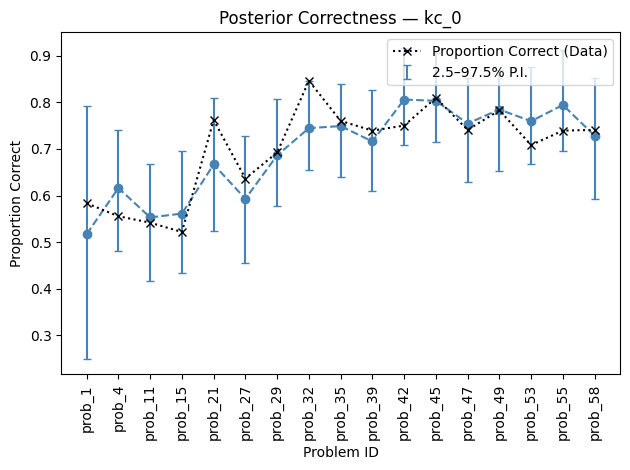

In [ ]:
plot_posterior_correctness(
    pred_post_draws,
    data=data_df,
    column_mapping=col_mapping,
    kc="kc_0",
    type="preds",
    trajectory=True,
    frac=0.5,
)